# LSTM-VAE Anomaly Detector v3 — Mejor Config Optuna
## Dataset: SWaT A12 (Marzo 2026)

### Contexto

| Version | ROC-AUC | Cambio principal |
|---------|---------|------------------|
| v1      | 0.5222  | Baseline (posterior collapse) |
| v2      | 0.7571  | Fix: beta=0.1, hidden=128, latent=64 |
| **v3**  | **TBD** | **Mejor config Optuna (trial #2, AUC=0.7946 en trial)** |

### Mejores hiperparametros encontrados por Optuna

| Parametro | v2 | **v3 (Optuna)** | Observacion |
|---|---|---|---|
| `hidden_size` | 128 | **192** | Mas capacidad |
| `num_layers`  | 2   | **1**   | Una sola capa — menos overfitting |
| `latent_dim`  | 64  | **96**  | Bottleneck mas rico |
| `dropout`     | 0.20 | **0.276** | Mas regularizacion |
| `beta`        | 0.10 | **0.016** | KL casi libre — prioriza reconstruccion |
| `alpha`       | 0.90 | **0.889** | Peso continuas calibrado |
| `lr`          | 5e-4 | **1.07e-4** | LR mas conservador |
| `batch_size`  | 128  | **64** | Gradientes mas ruidosos = mejor generalizacion |

### Flujo

```
02b_v3 (este notebook):
  1. Carga hiperparametros desde optuna_best_config.json
  2. Entrena LSTM-VAE con 150 epochs / patience=20
  3. Evalua sobre TODOS los datos del CSV (normales + ataques)
  4. Reporta ROC-AUC, F1, Recall, FPR directamente
```


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV     = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
# Config del Optuna LSTM-VAE (diferente al Conv1D)
OPTUNA_CFG  = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
SAVE_DIR    = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_v3'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('CSV:', RAW_CSV.exists())
print('Optuna cfg:', OPTUNA_CFG.exists())
print('Save dir:', SAVE_DIR)


CSV: True
Optuna cfg: True
Save dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_v3


## 2. Hiperparametros

Se cargan directamente desde `optuna_best_config.json` del estudio
`lstm_vae_a12_optuna_v1`. Todos los hiperparametros de arquitectura y
entrenamiento vienen del mejor trial (#2, AUC=0.7946).

Los unicos valores fijos (no buscados por Optuna) son:
- `WINDOW_SIZE = 60` — mismo que Conv1D
- `CLIP_VAL = 5.0` — mismo que Conv1D  
- `MAX_EPOCHS = 150`, `PATIENCE = 20` — reentrenamiento completo


In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
STRIDE          = int(optuna_cfg['stride'])

bp = optuna_cfg['best_params']  # mejores params del trial

# Hiperparametros de arquitectura (desde Optuna)
WINDOW_SIZE  = int(optuna_cfg['window_size'])
HIDDEN_SIZE  = int(bp['hidden_size'])
NUM_LAYERS   = int(bp['num_layers'])
LATENT_DIM   = int(bp['latent_dim'])
DISC_HIDDEN  = int(optuna_cfg['disc_hidden'])
BETA         = float(bp['beta'])
ALPHA        = float(bp['alpha'])
DROPOUT      = float(bp['dropout'])
LR           = float(bp['lr'])
BATCH_SIZE   = int(bp['batch_size'])

# Fijos
CLIP_VAL     = float(optuna_cfg['clip_val'])
MAX_EPOCHS   = 150
PATIENCE     = 20

print(f'--- Config cargada del mejor trial Optuna ---')
print(f'AUC en Optuna (trial): {optuna_cfg["best_auc_optuna"]:.4f}')
print(f'window={WINDOW_SIZE} | stride={STRIDE} | clip={CLIP_VAL}')
print(f'hidden={HIDDEN_SIZE} | layers={NUM_LAYERS} | latent={LATENT_DIM} | disc_hidden={DISC_HIDDEN}')
print(f'beta={BETA:.4f} | alpha={ALPHA:.4f} | dropout={DROPOUT:.4f}')
print(f'lr={LR:.2e} | batch={BATCH_SIZE}')
print(f'cont_cols={len(continuous_cols)} | disc_cols={len(discrete_cols)}')


--- Config cargada del mejor trial Optuna ---
AUC en Optuna (trial): 0.7946
window=60 | stride=10 | clip=5.0
hidden=192 | layers=1 | latent=96 | disc_hidden=64
beta=0.0161 | alpha=0.8891 | dropout=0.2761
lr=1.07e-04 | batch=64
cont_cols=31 | disc_cols=31


## 3. Carga y preprocesamiento

Identico a Conv1D: split cronologico 60/20/20, warmup de 120s,
imputacion con modas del train, StandardScaler + clip(-5, 5).

In [5]:
META_COLS = ['attack_label','attack_id','attack_name','attack_targets','attack_start_time','attack_end_time']

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

df_all = df_raw[['t_stamp','attack_label']+feature_cols].copy()
for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input', np.nan), errors='coerce')

WARMUP  = 120
df_work = df_all[df_all['attack_label']==0][['t_stamp']+feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n        = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

print(f'Normal: {len(df_work):,} | Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Normal: 25,620 | Train: 15,372 | Val: 5,124 | Test: 5,124


In [6]:
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)
disc_max = df_train[discrete_cols].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values),
        -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

rng = df_train_sc[continuous_cols].values.min(), df_train_sc[continuous_cols].values.max()
print(f'Train cont tras clip: [{rng[0]:.2f}, {rng[1]:.2f}]  (esperado: [-5, 5])')


Train cont tras clip: [-5.00, 5.00]  (esperado: [-5, 5])


## 4. Ventanas

**Diferencia clave vs Conv1D:** las ventanas continuas se dejan en formato
`(N, T, C)` — secuencia primero — porque LSTM espera esa forma. El Conv1D
necesitaba `(N, C, T)` (canales primero) y por eso habia un `np.transpose`.

Las ventanas discretas siguen siendo summary stats por ventana (misma funcion).

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, discrete_cols):
    """Mismo resumen estadistico que Conv1D: mode, transitions, nunique, dominance."""
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    """Retorna:
       cw: (N, T, C)   <- forma LSTM (sin transponer)
       dw: (N, disc_feat_dim)  <- summary stats discretas
    """
    raw_c = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    raw_d = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    if len(raw_c) == 0:
        return None, None
    # raw_c ya es (N, T, C) — sin transponer (diferencia vs Conv1D)
    disc_summary = summarize_discrete_windows(raw_d, discrete_cols).values.astype(np.float32)
    return raw_c, disc_summary

X_tr_c, X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c, X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)
X_te_c, X_te_d = build_windows(df_test_sc,  WINDOW_SIZE, STRIDE)

print(f'Train: {X_tr_c.shape}  (N, T, C)')
print(f'Val  : {X_va_c.shape}')
print(f'Test : {X_te_c.shape}')
print(f'Disc summary dim: {X_tr_d.shape[1]}')


Train: (1532, 60, 31)  (N, T, C)
Val  : (507, 60, 31)
Test : (507, 60, 31)
Disc summary dim: 124


## 5. Arquitectura LSTM-VAE Hibrido

```
Continuas (N,T,C) ──► LSTMEncoder ──► mu, logvar ──► z (reparametrizacion)
                                                        │
                                                        ▼
                                               LSTMDecoder ──► x_hat (N,T,C)

Discretas (N,D) ────► MLPEncoder ──► h_d ──► MLPDecoder ──► xd_hat (N,D)
```

**Perdida de entrenamiento (ELBO hibrido):**
```
L = alpha * (MSE_cont + beta * KL) + (1-alpha) * MSE_disc
```

**Score de anomalia (solo reconstruccion, sin KL):**
```
score = alpha * MSE_cont + (1-alpha) * MSE_disc
```
La KL se omite del score porque en inferencia el modelo aprende a
mapear casi todo cerca de N(0,I) — la informacion discriminativa esta
en el error de reconstruccion, no en la divergencia.

In [8]:
class LSTMEncoder(nn.Module):
    """LSTM encoder: (N,T,C) -> (mu, logvar) de dimension latent_dim."""
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop     = nn.Dropout(dropout)
        self.fc_mu    = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar= nn.Linear(hidden_size, latent_dim)

    def forward(self, x):
        _, (h, _) = self.lstm(x)          # h: (num_layers, N, hidden)
        h_last = self.drop(h[-1])          # ultima capa: (N, hidden)
        return self.fc_mu(h_last), self.fc_logvar(h_last)


class LSTMDecoder(nn.Module):
    """LSTM decoder: z (N, latent_dim) -> x_hat (N, T, output_size).
    
    El estado oculto inicial se inicializa con una proyeccion de z,
    y la entrada al LSTM es z repetido T veces (teacher-forcing libre).
    """
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.hidden_size= hidden_size
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)   # inicializar h0
        self.lstm = nn.LSTM(
            latent_dim, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop   = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, z):
        N = z.size(0)
        # Estado oculto inicial derivado de z
        h0 = torch.tanh(self.fc_h0(z))                          # (N, hidden)
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)      # (L, N, hidden)
        c0 = torch.zeros_like(h0)
        # Entrada: z repetido T veces
        z_rep = z.unsqueeze(1).repeat(1, self.seq_len, 1)       # (N, T, latent)
        out, _ = self.lstm(z_rep, (h0, c0))                     # (N, T, hidden)
        return self.fc_out(self.drop(out))                       # (N, T, C)


class HybridLSTMVAE(nn.Module):
    """LSTM-VAE con rama discreta MLP.
    
    Continuas: LSTM encoder/decoder con espacio latente gaussiano.
    Discretas:  MLP encoder/decoder deterministico (mismas features que Conv1D).
    """
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=64, num_layers=2, latent_dim=32,
                 disc_hidden=64, dropout=0.2):
        super().__init__()
        # Rama continua — VAE
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        # Rama discreta — AE deterministico (igual que Conv1D)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU()
        )
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim)
        )

    def reparameterize(self, mu, logvar):
        """Truco de reparametrizacion: z = mu + eps * sigma."""
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu   # En inferencia usamos la media directamente

    def forward(self, xc, xd):
        # Continua
        mu, logvar = self.encoder_cont(xc)
        z          = self.reparameterize(mu, logvar)
        xc_hat     = self.decoder_cont(z)
        # Discreta
        h_d   = self.encoder_disc(xd)
        xd_hat= self.decoder_disc(h_d)
        return xc_hat, xd_hat, mu, logvar


def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    """ELBO hibrido:
       L = alpha * (MSE_cont + beta * KL) + (1-alpha) * MSE_disc
    """
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    # KL divergencia: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * (mse_c + beta * kl) + (1 - alpha) * mse_d, mse_c, mse_d, kl


# Instanciar modelo
model = HybridLSTMVAE(
    cont_size  = X_tr_c.shape[2],   # C (numero de variables continuas)
    seq_len    = WINDOW_SIZE,
    disc_dim   = X_tr_d.shape[1],
    hidden_size= HIDDEN_SIZE,
    num_layers = NUM_LAYERS,
    latent_dim = LATENT_DIM,
    disc_hidden= DISC_HIDDEN,
    dropout    = DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {n_params:,}')
print(f'  Encoder LSTM: {sum(p.numel() for p in model.encoder_cont.parameters()):,}')
print(f'  Decoder LSTM: {sum(p.numel() for p in model.decoder_cont.parameters()):,}')
print(f'  Encoder disc: {sum(p.numel() for p in model.encoder_disc.parameters()):,}')
print(f'  Decoder disc: {sum(p.numel() for p in model.decoder_disc.parameters()):,}')


Parametros totales: 477,435
  Encoder LSTM: 209,856
  Decoder LSTM: 247,327
  Encoder disc: 10,080
  Decoder disc: 10,172


## 6. Entrenamiento

In [9]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                  torch.tensor(X_tr_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                  torch.tensor(X_va_d, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

best_val, best_wts, no_improve, best_ep = float('inf'), None, 0, 1
train_hist, val_hist = [], []
# Historial desglosado para diagnostico
hist_mse_c, hist_mse_d, hist_kl = [], [], []

print(f'Batch:{BATCH_SIZE} | LR:{LR:.2e} | MaxEp:{MAX_EPOCHS} | Patience:{PATIENCE}')
print(f'beta={BETA} | alpha={ALPHA}')

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    tl = tmse_c = tmse_d = tkl = 0.0
    for xc, xd in train_loader:
        xc, xd = xc.to(device), xd.to(device)
        optimizer.zero_grad()
        xc_hat, xd_hat, mu, logvar = model(xc, xd)
        loss, mc, md, kl = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # estabilidad LSTM
        optimizer.step()
        tl += loss.item(); tmse_c += mc.item(); tmse_d += md.item(); tkl += kl.item()

    nb = len(train_loader)
    tl /= nb; tmse_c /= nb; tmse_d /= nb; tkl /= nb

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for xc, xd in val_loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, ALPHA, BETA)[0].item()
    vl /= len(val_loader)

    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    hist_mse_c.append(tmse_c); hist_mse_d.append(tmse_d); hist_kl.append(tkl)

    if vl < best_val - 1e-6:
        best_val = vl
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
        best_ep  = epoch
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} (mse_c={tmse_c:.4f} kl={tkl:.4f}) '
              f'| Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve >= PATIENCE:
        print(f'Early stop ep{epoch}.')
        break

model.load_state_dict(best_wts)
model.eval()
print(f'\nMejor val:{best_val:.5f} ep{best_ep}')


Batch:64 | LR:1.07e-04 | MaxEp:150 | Patience:20
beta=0.016119044727609194 | alpha=0.8891318438200286
Ep   10/150 | Train:0.30519 (mse_c=0.3307 kl=0.3767) | Val:0.44802 | Best:0.44802(ep10)
Ep   20/150 | Train:0.15894 (mse_c=0.1630 kl=0.6672) | Val:0.39654 | Best:0.39654(ep20)
Ep   30/150 | Train:0.11534 (mse_c=0.1116 kl=0.8226) | Val:0.35589 | Best:0.35589(ep30)
Ep   40/150 | Train:0.09433 (mse_c=0.0886 kl=0.8227) | Val:0.35076 | Best:0.34851(ep36)
Ep   50/150 | Train:0.08585 (mse_c=0.0799 kl=0.7993) | Val:0.34826 | Best:0.34481(ep45)
Ep   60/150 | Train:0.07979 (mse_c=0.0738 kl=0.7740) | Val:0.34190 | Best:0.34190(ep60)
Ep   70/150 | Train:0.07523 (mse_c=0.0696 kl=0.7377) | Val:0.35394 | Best:0.34190(ep60)
Ep   80/150 | Train:0.07268 (mse_c=0.0670 kl=0.7339) | Val:0.35246 | Best:0.34190(ep60)
Early stop ep80.

Mejor val:0.34190 ep60


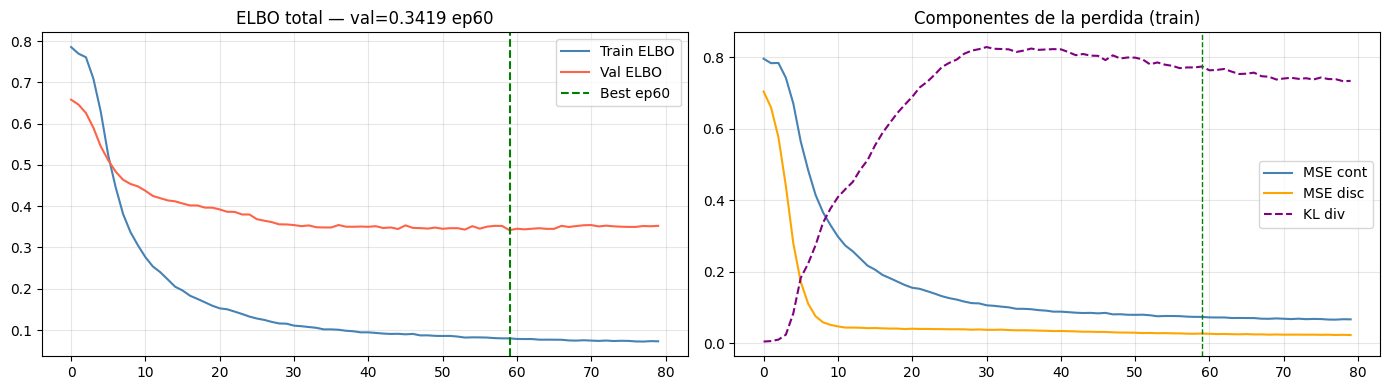

In [10]:
# Curva de entrenamiento + desglose de componentes
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_hist, label='Train ELBO', color='steelblue', lw=1.5)
axes[0].plot(val_hist,   label='Val ELBO',   color='tomato',    lw=1.5)
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title(f'ELBO total — val={best_val:.4f} ep{best_ep}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_mse_c, label='MSE cont', color='steelblue', lw=1.5)
axes[1].plot(hist_mse_d, label='MSE disc', color='orange',    lw=1.5)
axes[1].plot(hist_kl,    label='KL div',   color='purple',    lw=1.5, linestyle='--')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1)
axes[1].set_title('Componentes de la perdida (train)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curve.png'), dpi=120, bbox_inches='tight')
plt.show()


## 7. Evaluacion supervisada con ataques etiquetados

Identico a Conv1D: se cargan TODAS las filas del CSV (normales + ataques),
se aplica el mismo scaler con clip(-5, 5), y se calculan las metricas.

**Score**: `alpha * MSE_cont + (1-alpha) * MSE_disc` (sin KL).

In [11]:
def recon_errors(model, Xc, Xd, alpha, bs=256):
    """Calcula errores de reconstruccion por ventana.
    Xc: (N, T, C)  — formato LSTM
    Xd: (N, disc_dim)
    Retorna: ec (cont), ed (disc), scores combinados
    """
    loader = DataLoader(
        TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                      torch.tensor(Xd, dtype=torch.float32)),
        batch_size=bs, shuffle=False
    )
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)  # mu como z en inferencia
            # MSE por ventana: media sobre T y C
            ec_l.extend(torch.mean((xc_hat - xc)**2, dim=(1, 2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat - xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l)
    ed = np.array(ed_l)
    return ec, ed, alpha * ec + (1 - alpha) * ed


# Escalar TODO el CSV
df_eval = df_all[['t_stamp', 'attack_label'] + feature_cols].copy()
df_eval[feature_cols]       = df_eval[feature_cols].fillna(modes_train)
df_eval[continuous_cols]    = np.clip(scaler_cont.transform(df_eval[continuous_cols].values), -CLIP_VAL, CLIP_VAL)
df_eval[discrete_cols]      = (df_eval[discrete_cols] / disc_max).clip(0, 1)

print(f'Rango continuas (todo CSV escalado+clip): [{df_eval[continuous_cols].values.min():.2f}, {df_eval[continuous_cols].values.max():.2f}]')

# Ventanas etiquetadas — continuas en (N,T,C) sin transponer
cont_arr = df_eval[continuous_cols].values.astype(np.float32)
disc_arr = df_eval[discrete_cols].values.astype(np.float32)
labs_arr = df_eval['attack_label'].values

wins_c, wins_d, wins_y = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    wins_y.append(int(np.any(labs_arr[s:s+WINDOW_SIZE] == 1)))

X_eval_c = np.array(wins_c, dtype=np.float32)   # (N, T, C)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
y_eval   = np.array(wins_y, dtype=int)

print(f'Ventanas totales: {len(y_eval)} | Normal: {(y_eval==0).sum()} | Ataque: {(y_eval==1).sum()} ({100*y_eval.mean():.1f}%)')


Rango continuas (todo CSV escalado+clip): [-5.00, 5.00]
Ventanas totales: 2881 | Normal: 2519 | Ataque: 362 (12.6%)


Error medio NORMAL: 0.1579
Error medio ATAQUE: 0.3821
Ratio ataque/normal: 2.42x  (>1.5 indica buena separacion)


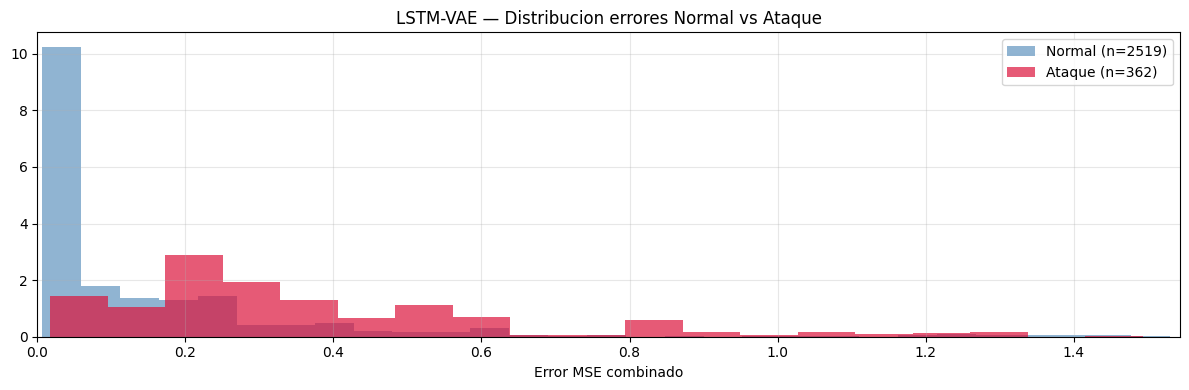

In [12]:
# Calcular scores
ec, ed, scores = recon_errors(model, X_eval_c, X_eval_d, ALPHA)

mn = scores[y_eval == 0].mean()
ma = scores[y_eval == 1].mean()
print(f'Error medio NORMAL: {mn:.4f}')
print(f'Error medio ATAQUE: {ma:.4f}')
print(f'Ratio ataque/normal: {ma/mn:.2f}x  (>1.5 indica buena separacion)')

# Distribucion de errores
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(scores[y_eval == 0], bins=80, alpha=0.6, density=True, color='steelblue', label=f'Normal (n={(y_eval==0).sum()})')
ax.hist(scores[y_eval == 1], bins=40, alpha=0.7, density=True, color='crimson',   label=f'Ataque (n={(y_eval==1).sum()})')
ax.set_xlabel('Error MSE combinado')
ax.set_title('LSTM-VAE — Distribucion errores Normal vs Ataque')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(scores, 99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'error_dist_eval.png'), dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# Metricas supervisadas (identico a Conv1D)
auc    = roc_auc_score(y_eval, scores)
pr_auc = average_precision_score(y_eval, scores)

fprs, tprs, thrs = roc_curve(y_eval, scores)
j_idx      = int(np.argmax(tprs - fprs))
tau_youden = float(thrs[j_idx])

precs, recs, thrs_pr = precision_recall_curve(y_eval, scores)
n   = min(len(thrs_pr), len(precs) - 1)
f1s = 2 * precs[:n] * recs[:n] / (precs[:n] + recs[:n] + 1e-10)
f1_max = float(f1s.max())
tau_f1 = float(thrs_pr[f1s.argmax()])

def metrics_at(tau):
    pred = (scores > tau).astype(int)
    tp = int(((pred==1)&(y_eval==1)).sum()); fp = int(((pred==1)&(y_eval==0)).sum())
    tn = int(((pred==0)&(y_eval==0)).sum()); fn = int(((pred==0)&(y_eval==1)).sum())
    p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
    return {'tau':float(tau),'precision':float(p),'recall':float(r),
            'f1':float(2*p*r/(p+r+1e-10)),'fpr':float(fp/(fp+tn+1e-10)),
            'tp':tp,'fp':fp,'tn':tn,'fn':fn}

m_youden = metrics_at(tau_youden)
m_f1     = metrics_at(tau_f1)

print('='*55)
print(f'ROC-AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}')
print()
print(f'tau_Youden = {tau_youden:.4f}')
print(f'  Recall={m_youden["recall"]:.3f} | Precision={m_youden["precision"]:.3f} | F1={m_youden["f1"]:.3f} | FPR={m_youden["fpr"]:.3f}')
print()
print(f'tau_F1max = {tau_f1:.4f}  (F1={f1_max:.3f})')
print(f'  Recall={m_f1["recall"]:.3f} | Precision={m_f1["precision"]:.3f} | FPR={m_f1["fpr"]:.3f}')
print('='*55)


ROC-AUC: 0.7963 | PR-AUC: 0.2930

tau_Youden = 0.1805
  Recall=0.804 | Precision=0.290 | F1=0.426 | FPR=0.283

tau_F1max = 0.2293  (F1=0.441)
  Recall=0.685 | Precision=0.324 | FPR=0.206


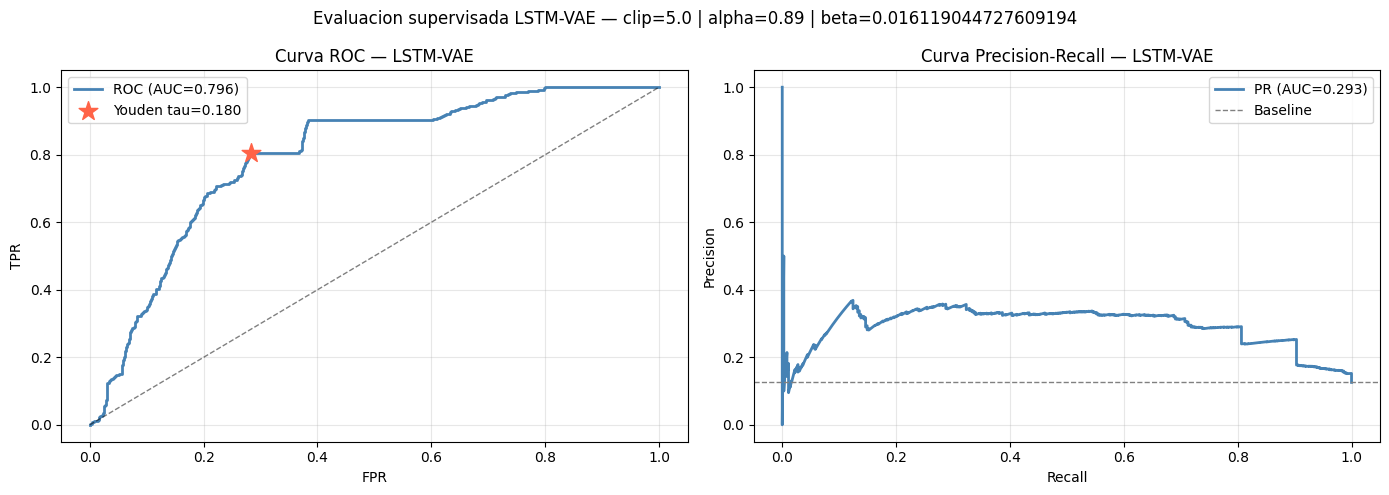

In [14]:
# Curvas ROC y PR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fprs, tprs, color='steelblue', lw=2, label=f'ROC (AUC={auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
axes[0].scatter(m_youden['fpr'], m_youden['recall'], marker='*', s=200,
                color='tomato', zorder=5, label=f'Youden tau={tau_youden:.3f}')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC — LSTM-VAE'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(recs, precs, color='steelblue', lw=2, label=f'PR (AUC={pr_auc:.3f})')
axes[1].axhline(y_eval.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — LSTM-VAE'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Evaluacion supervisada LSTM-VAE — clip={CLIP_VAL} | alpha={ALPHA:.2f} | beta={BETA}', fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'roc_pr_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


## 8. Guardar artefactos

In [15]:
torch.save(model.state_dict(), SAVE_DIR / 'model_state.pt')

tau_dict = {f'p{str(p).replace(".","_")}': float(np.percentile(scores[y_eval==0], p))
            for p in [90, 95, 97.5, 99, 99.5]}
tau_dict['youden'] = tau_youden
tau_dict['f1_max'] = tau_f1

with open(SAVE_DIR / 'tau_dict.json', 'w') as f:
    json.dump(tau_dict, f, indent=4)

with open(SAVE_DIR / 'columns_config.json', 'w') as f:
    json.dump({'continuous_cols': continuous_cols,
               'discrete_cols':   discrete_cols,
               'feature_cols':    feature_cols}, f, indent=4)

with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump({
        'version':      'a12_lstm_vae_v3_optuna',
        'dataset':      'SWaT A12 Mar 2026',
        'architecture': 'LSTM-VAE Hybrid v3 (Optuna best trial #2)',
        'clip_val':     CLIP_VAL,
        'split':        'chronological_60_20_20',
        'window_size':  WINDOW_SIZE,
        'stride':       STRIDE,
        'alpha':        float(ALPHA),
        'beta':         float(BETA),
        'best_epoch':   best_ep,
        'best_val_loss':float(best_val),
        'n_windows_train': int(len(X_tr_c)),
        'n_windows_val':   int(len(X_va_c)),
        'cont_size':    int(X_tr_c.shape[2]),
        'disc_dim':     int(X_tr_d.shape[1]),
        'model_params': {
            'hidden_size':  HIDDEN_SIZE,
            'num_layers':   NUM_LAYERS,
            'latent_dim':   LATENT_DIM,
            'disc_hidden':  DISC_HIDDEN,
            'dropout':      DROPOUT,
            'lr':           LR,
            'batch_size':   BATCH_SIZE,
        },
        'eval_supervised': {
            'roc_auc':           float(auc),
            'pr_auc':            float(pr_auc),
            'f1_youden':         float(m_youden['f1']),
            'recall_youden':     float(m_youden['recall']),
            'fpr_youden':        float(m_youden['fpr']),
            'f1_max':            float(f1_max),
            'mean_error_normal': float(mn),
            'mean_error_attack': float(ma),
        },
        'continuous_cols': continuous_cols,
        'discrete_cols':   discrete_cols,
        'feature_cols':    feature_cols,
        'scenarios':       ['real_only', 'synthetic_only', 'real_plus_synthetic'],
        'optuna_source':   'lstm_vae_a12_optuna_v1 / trial #2 / AUC=0.7946',
        'score_formula':   'alpha * MSE_cont + (1-alpha) * MSE_disc  [KL solo en train]',
    }, f, indent=4)

print('Guardado en:', SAVE_DIR.resolve())
for fp in sorted(SAVE_DIR.iterdir()):
    print(f'  {fp.name}')


Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_v3
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_eval.png
  model_state.pt
  roc_pr_curves.png
  scaler_cont.pkl
  tau_dict.json
  training_curve.png
